SOLARIZACION

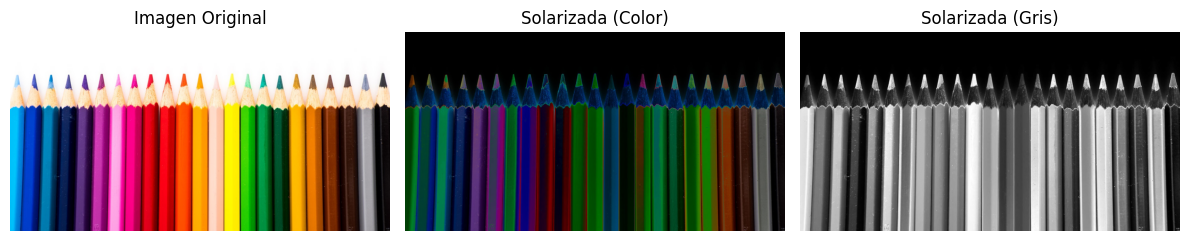

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def solarizacion(imagen, umbral):
    # APLICAMOS SOLARIZACION
    # El casteo a uint8 asegura que el resultado se mantenga en el rango de imagen
    img_sol = np.where(imagen < umbral, imagen, 255 - imagen).astype(np.uint8)
    return img_sol

# CORRECCIÓN DE RUTA: Según tu VS Code, la ruta debe incluir "clases/"
ruta_img = 'clases/img/colores.jpg'
imagen = cv2.imread(ruta_img)

# Verificación de seguridad
if imagen is None:
    print(f"Error: No se encontró la imagen en {ruta_img}")
else:
    # Convertimos a Gris
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

    #----
    umbral = 127
    img_fin_colores = solarizacion(imagen, umbral)
    img_fin_gray = solarizacion(img_gray, umbral)

    # --- MOSTRAMOS RESULTADOS ---
    plt.figure(figsize=(12, 6))

    # 1. Imagen Original (Convertida a RGB para Matplotlib)
    plt.subplot(1, 3, 1)
    plt.title('Imagen Original')
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    # 2. Imagen Solarizada a Color
    # IMPORTANTE: También hay que convertir el resultado a RGB para que no se vea azul/rojo invertido
    plt.subplot(1, 3, 2)
    plt.title('Solarizada (Color)')
    plt.imshow(cv2.cvtColor(img_fin_colores, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    # 3. Imagen Solarizada Grises
    plt.subplot(1, 3, 3)
    plt.title('Solarizada (Gris)')
    plt.imshow(img_fin_gray, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

POSTERIZAR

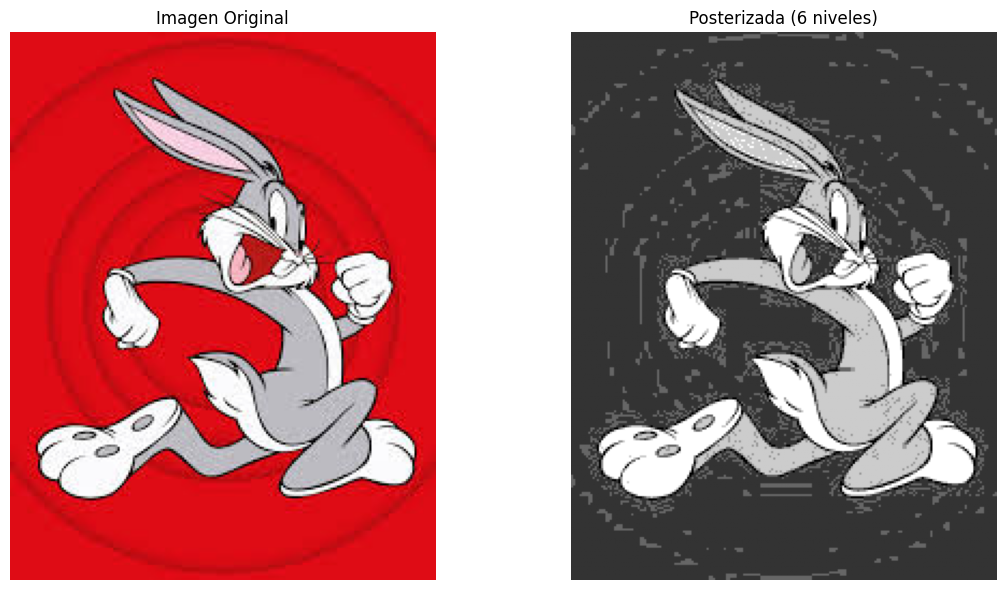

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def posterizar(imagen, niveles):
    # APLICAMOS POSTERIZACION
    # Calculamos el tamaño de cada salto de color
    factor_escala = 255 / (niveles - 1)
    
    # Aplicamos la reducción de niveles y aseguramos el rango 0-255
    img_pos = np.round(imagen / factor_escala) * factor_escala
    return np.clip(img_pos, 0, 255).astype(np.uint8)

# RUTA CORREGIDA: Incluyendo la carpeta 'clases'
ruta_yoshi = 'clases/img/conejo.png'
imagen = cv2.imread(ruta_yoshi)

if imagen is None:
    print(f"Error: No se encontró a Yoshi en {ruta_yoshi}. Revisa si el nombre es yoshi.jpeg o yoshi.jpg")
else:
    # Convertimos a Gris para el proceso
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # Configuración de niveles (a menor número, más marcado el efecto)
    nivel = 6
    img_fin = posterizar(img_gray, nivel)

    # MOSTRAMOS RESULTADOS
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title('Imagen Original')
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f'Posterizada ({nivel} niveles)')
    plt.imshow(img_fin, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

juntar todo 

✅ Imágenes guardadas con éxito en: clases/img/


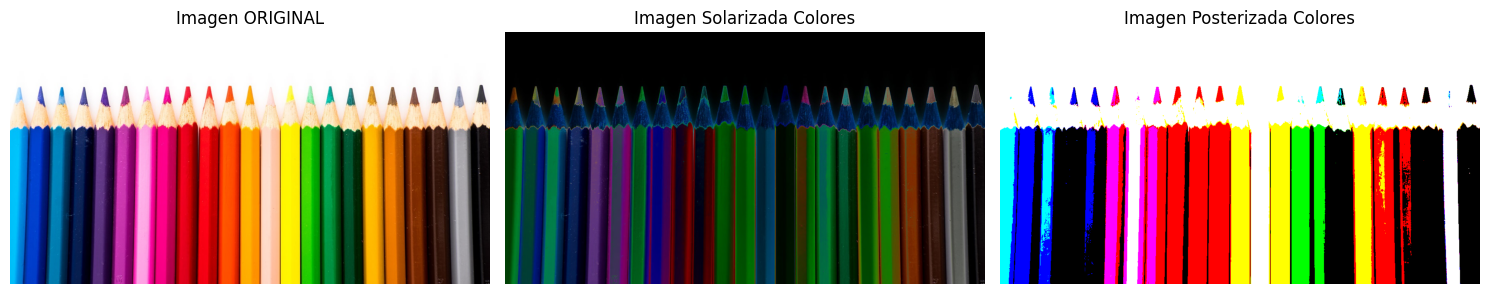

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def solarizar(imagen, umbral):
    # APLICAMOS SOLARIZACION
    img_sol = np.where(imagen < umbral, imagen, 255 - imagen)
    return img_sol.astype(np.uint8)

def posterizar(imagen, niveles):
    # APLICAMOS POSTERIZACION
    # Usar (niveles - 1) ayuda a que el rango cubra hasta el 255 correctamente
    factor_escala = 255 / (niveles - 1)
    img_pos = np.round(imagen / factor_escala) * factor_escala
    return np.clip(img_pos, 0, 255).astype(np.uint8)

# --- CONFIGURACIÓN DE RUTAS ---
# Ajustamos a la ruta de tu proyecto en Univalle
carpeta_img = 'clases/img/'
nombre_archivo = 'colores.jpg'
ruta_lectura = os.path.join(carpeta_img, nombre_archivo)

imagen = cv2.imread(ruta_lectura)

if imagen is None:
    print(f"❌ Error: No se encontró la imagen en {ruta_lectura}")
else:
    # --- PROCESAMIENTO ---
    umbral = 127
    imagen_sol = solarizar(imagen, umbral)

    niveles = 2
    imagen_pos = posterizar(imagen, niveles)

    # --- GUARDAR IMÁGENES EN LA CARPETA ---
    # Guardamos los resultados usando OpenCV (recuerda que OpenCV guarda en BGR)
    cv2.imwrite(os.path.join(carpeta_img, 'resultado_solarizado.jpg'), imagen_sol)
    cv2.imwrite(os.path.join(carpeta_img, 'resultado_posterizado.jpg'), imagen_pos)
    print(f"✅ Imágenes guardadas con éxito en: {carpeta_img}")

    # --- MOSTRAR RESULTADOS ---
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title('Imagen ORIGINAL')
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title('Imagen Solarizada Colores')
    plt.imshow(cv2.cvtColor(imagen_sol, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title('Imagen Posterizada Colores')
    plt.imshow(cv2.cvtColor(imagen_pos, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

FALSO COLOR

✅ Imagen guardada como: clases/img/yoshi_falso_color.jpg


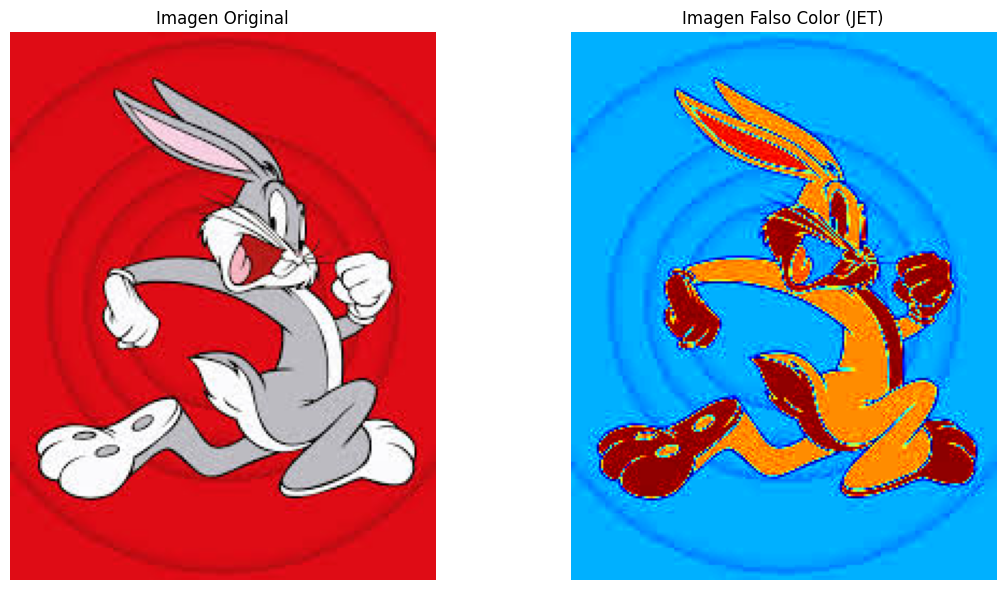

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os # <-- CAMBIO 1: Importamos os para manejar rutas de carpetas de forma segura

def falso_color(img_gray):
    # Normalizamos la imagen para asegurar que use todo el rango de 0 a 255
    escal_img = cv2.normalize(img_gray, None, 0, 255, cv2.NORM_MINMAX)
    # Aplicamos el mapa de color JET (Falso Color)
    falso_img = cv2.applyColorMap(escal_img, cv2.COLORMAP_JET)
    return falso_img

# --- CONFIGURACIÓN DE RUTA ---
# CAMBIO 2: Ajustamos la ruta para que incluya 'clases/' según tu estructura en VS Code
carpeta_img = 'clases/img/'
nombre_archivo = 'conejo.png' # Asegúrate de que este nombre coincida exactamente con el archivo en tu carpeta
ruta_lectura = os.path.join(carpeta_img, nombre_archivo)

imagen = cv2.imread(ruta_lectura)

if imagen is None:
    print(f"❌ Error: No se encontró la imagen en {ruta_lectura}")
else:
    # Convertimos a escala de grises para procesar
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # Aplicamos la función de falso color
    img_fin = falso_color(img_gray)

    # --- CAMBIO 3: Guardar el resultado en la carpeta img ---
    ruta_guardado = os.path.join(carpeta_img, 'yoshi_falso_color.jpg')
    cv2.imwrite(ruta_guardado, img_fin)
    print(f"✅ Imagen guardada como: {ruta_guardado}")

    # --- MOSTRAMOS RESULTADOS ---
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title('Imagen Original')
    # CAMBIO 4: Corregimos la visualización de la original (estaba en BGR, debe ser RGB)
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Imagen Falso Color (JET)')
    # CAMBIO 5: Corregimos el falso color (OpenCV genera BGR, Matplotlib usa RGB)
    plt.imshow(cv2.cvtColor(img_fin, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

ejemplo en la imagen 

✅ Carpeta creada: clases/img/resultados_colormaps
✅ Se han guardado 22 imágenes en: clases/img/resultados_colormaps


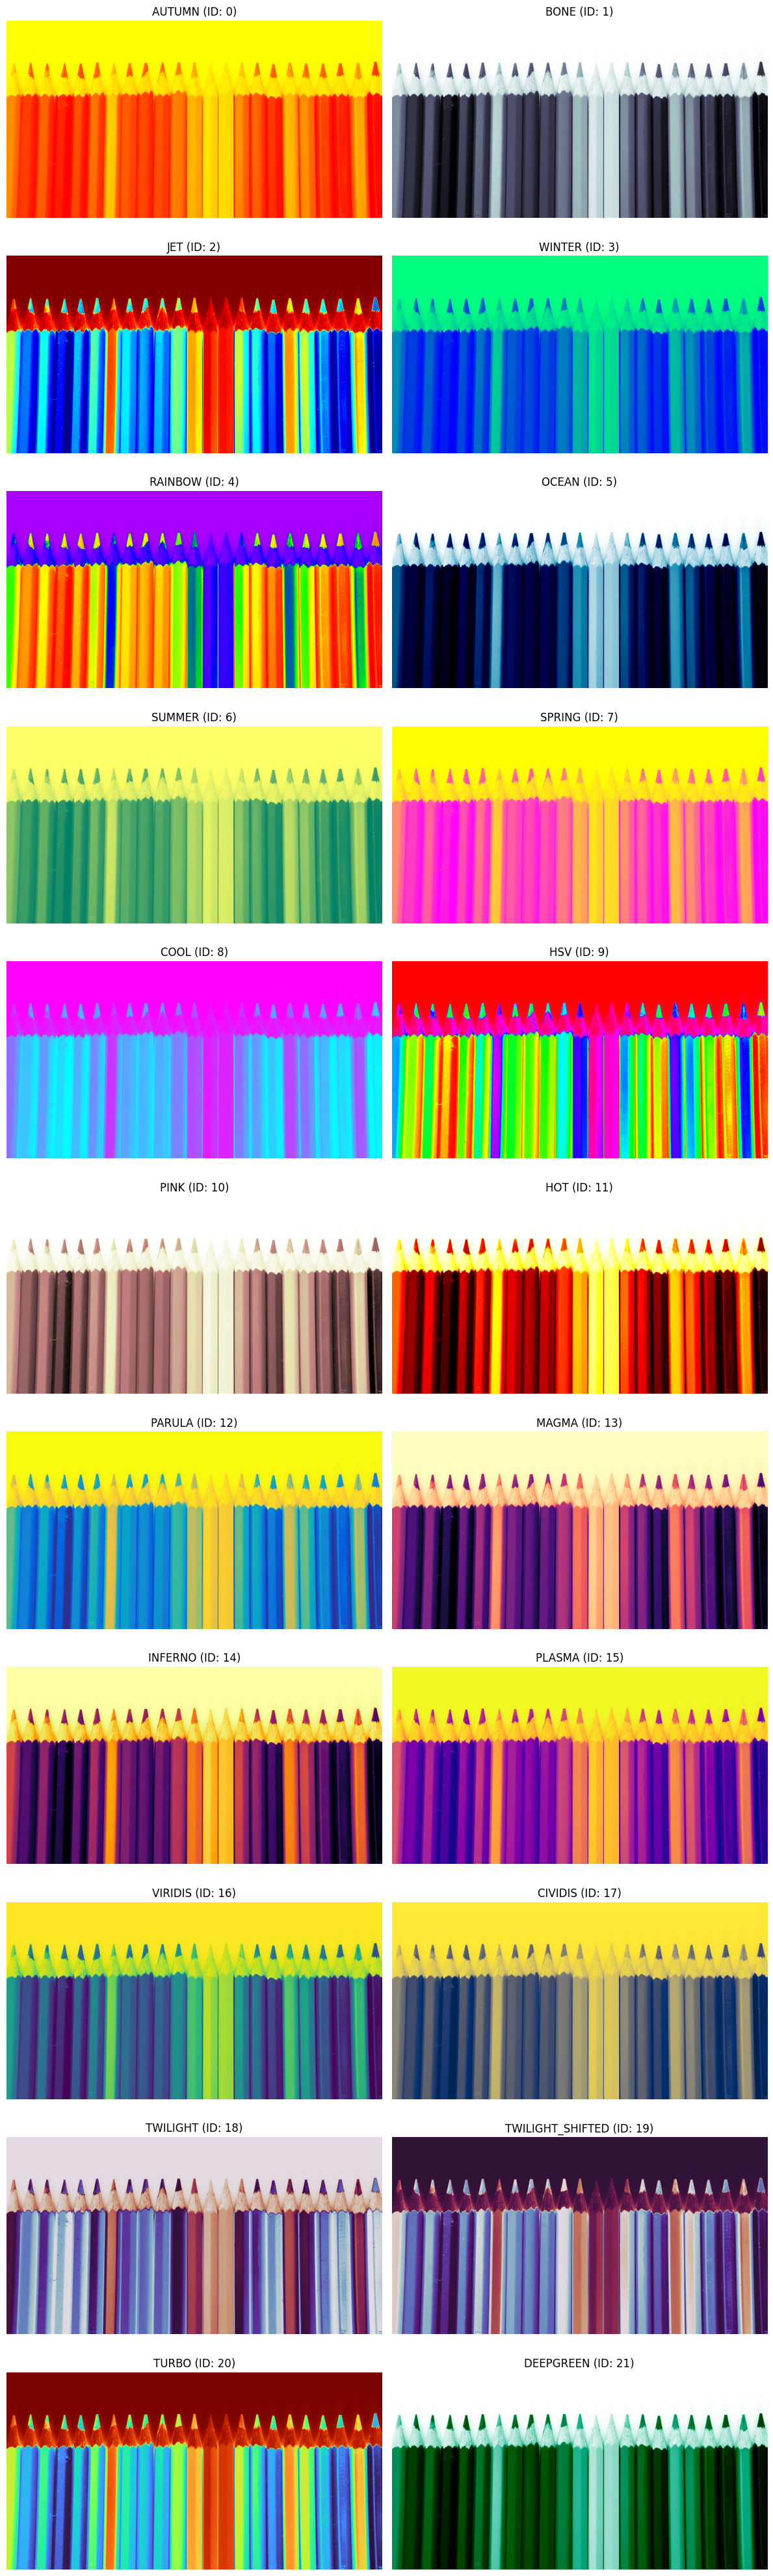

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os # <-- CAMBIO 1: Importamos os para manejar directorios

# --- CONFIGURACIÓN DE RUTAS ---
# CAMBIO 2: Ajustamos la ruta a tu estructura 'clases/img/'
carpeta_base = 'clases/img/'
# Creamos una subcarpeta para los resultados para mantener el orden
carpeta_resultados = os.path.join(carpeta_base, 'resultados_colormaps')

# CAMBIO 3: Si la carpeta de resultados no existe, la creamos automáticamente
if not os.path.exists(carpeta_resultados):
    os.makedirs(carpeta_resultados)
    print(f"✅ Carpeta creada: {carpeta_resultados}")

ruta_lectura = os.path.join(carpeta_base, 'colores.jpg')
imagen_bgr = cv2.imread(ruta_lectura)

if imagen_bgr is None:
    print(f"❌ Error: No se encontró la imagen en {ruta_lectura}")
else:
    imagen_gray = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)

    colormaps = [
        cv2.COLORMAP_AUTUMN, cv2.COLORMAP_BONE, cv2.COLORMAP_JET, cv2.COLORMAP_WINTER,
        cv2.COLORMAP_RAINBOW, cv2.COLORMAP_OCEAN, cv2.COLORMAP_SUMMER, cv2.COLORMAP_SPRING,
        cv2.COLORMAP_COOL, cv2.COLORMAP_HSV, cv2.COLORMAP_PINK, cv2.COLORMAP_HOT,
        cv2.COLORMAP_PARULA, cv2.COLORMAP_MAGMA, cv2.COLORMAP_INFERNO, cv2.COLORMAP_PLASMA,
        cv2.COLORMAP_VIRIDIS, cv2.COLORMAP_CIVIDIS, cv2.COLORMAP_TWILIGHT,
        cv2.COLORMAP_TWILIGHT_SHIFTED, cv2.COLORMAP_TURBO, cv2.COLORMAP_DEEPGREEN
    ]

    nombres = [
        "AUTUMN", "BONE", "JET", "WINTER", "RAINBOW", "OCEAN", "SUMMER", "SPRING",
        "COOL", "HSV", "PINK", "HOT", "PARULA", "MAGMA", "INFERNO", "PLASMA",
        "VIRIDIS", "CIVIDIS", "TWILIGHT", "TWILIGHT_SHIFTED", "TURBO", "DEEPGREEN"
    ]

    plt.figure(figsize=(12, 40))

    for i in range(len(colormaps)):
        # Procesamiento
        imagen_color = cv2.applyColorMap(imagen_gray, colormaps[i])
        
        # --- CAMBIO 4: Guardar cada imagen individualmente ---
        # El nombre del archivo será el nombre del colormap (ej: JET.jpg)
        nombre_archivo = f"{nombres[i]}.jpg"
        ruta_guardado = os.path.join(carpeta_resultados, nombre_archivo)
        cv2.imwrite(ruta_guardado, imagen_color) # Guardamos en BGR (formato nativo OpenCV)

        # Conversión para visualización en el Notebook
        imagen_rgb = cv2.cvtColor(imagen_color, cv2.COLOR_BGR2RGB)

        plt.subplot(11, 2, i + 1)
        plt.imshow(imagen_rgb)
        plt.title(nombres[i] + f' (ID: {colormaps[i]})')
        plt.axis('off')

    print(f"✅ Se han guardado {len(colormaps)} imágenes en: {carpeta_resultados}")
    plt.tight_layout()
    plt.show()